<a href="https://colab.research.google.com/github/sandeshghimire2/DL_practice/blob/main/Non_linear_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.utils import plot_model
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### Create a non linear model

In [52]:
inputs = Input(shape=(10,),name="Input Layer")
layer1 = Dense(64, activation='relu',name="Dense layer 1")(inputs)

### Create branch
branch1 = Dense(32, activation='relu',name="Branch 1")(layer1)
branch11 = Dense(16, activation='relu',name="Branch 11")(branch1)

### Create branch2
branch2 = Dense(32, activation='relu',name="Branch 2")(layer1)
branch21 = Dense(16, activation='relu',name="Branch 21")(branch2)

### Concat model

In [53]:
merged = Concatenate()([branch11, branch21])

In [55]:
model1 = Model(inputs=inputs, outputs=merged)

### Plot

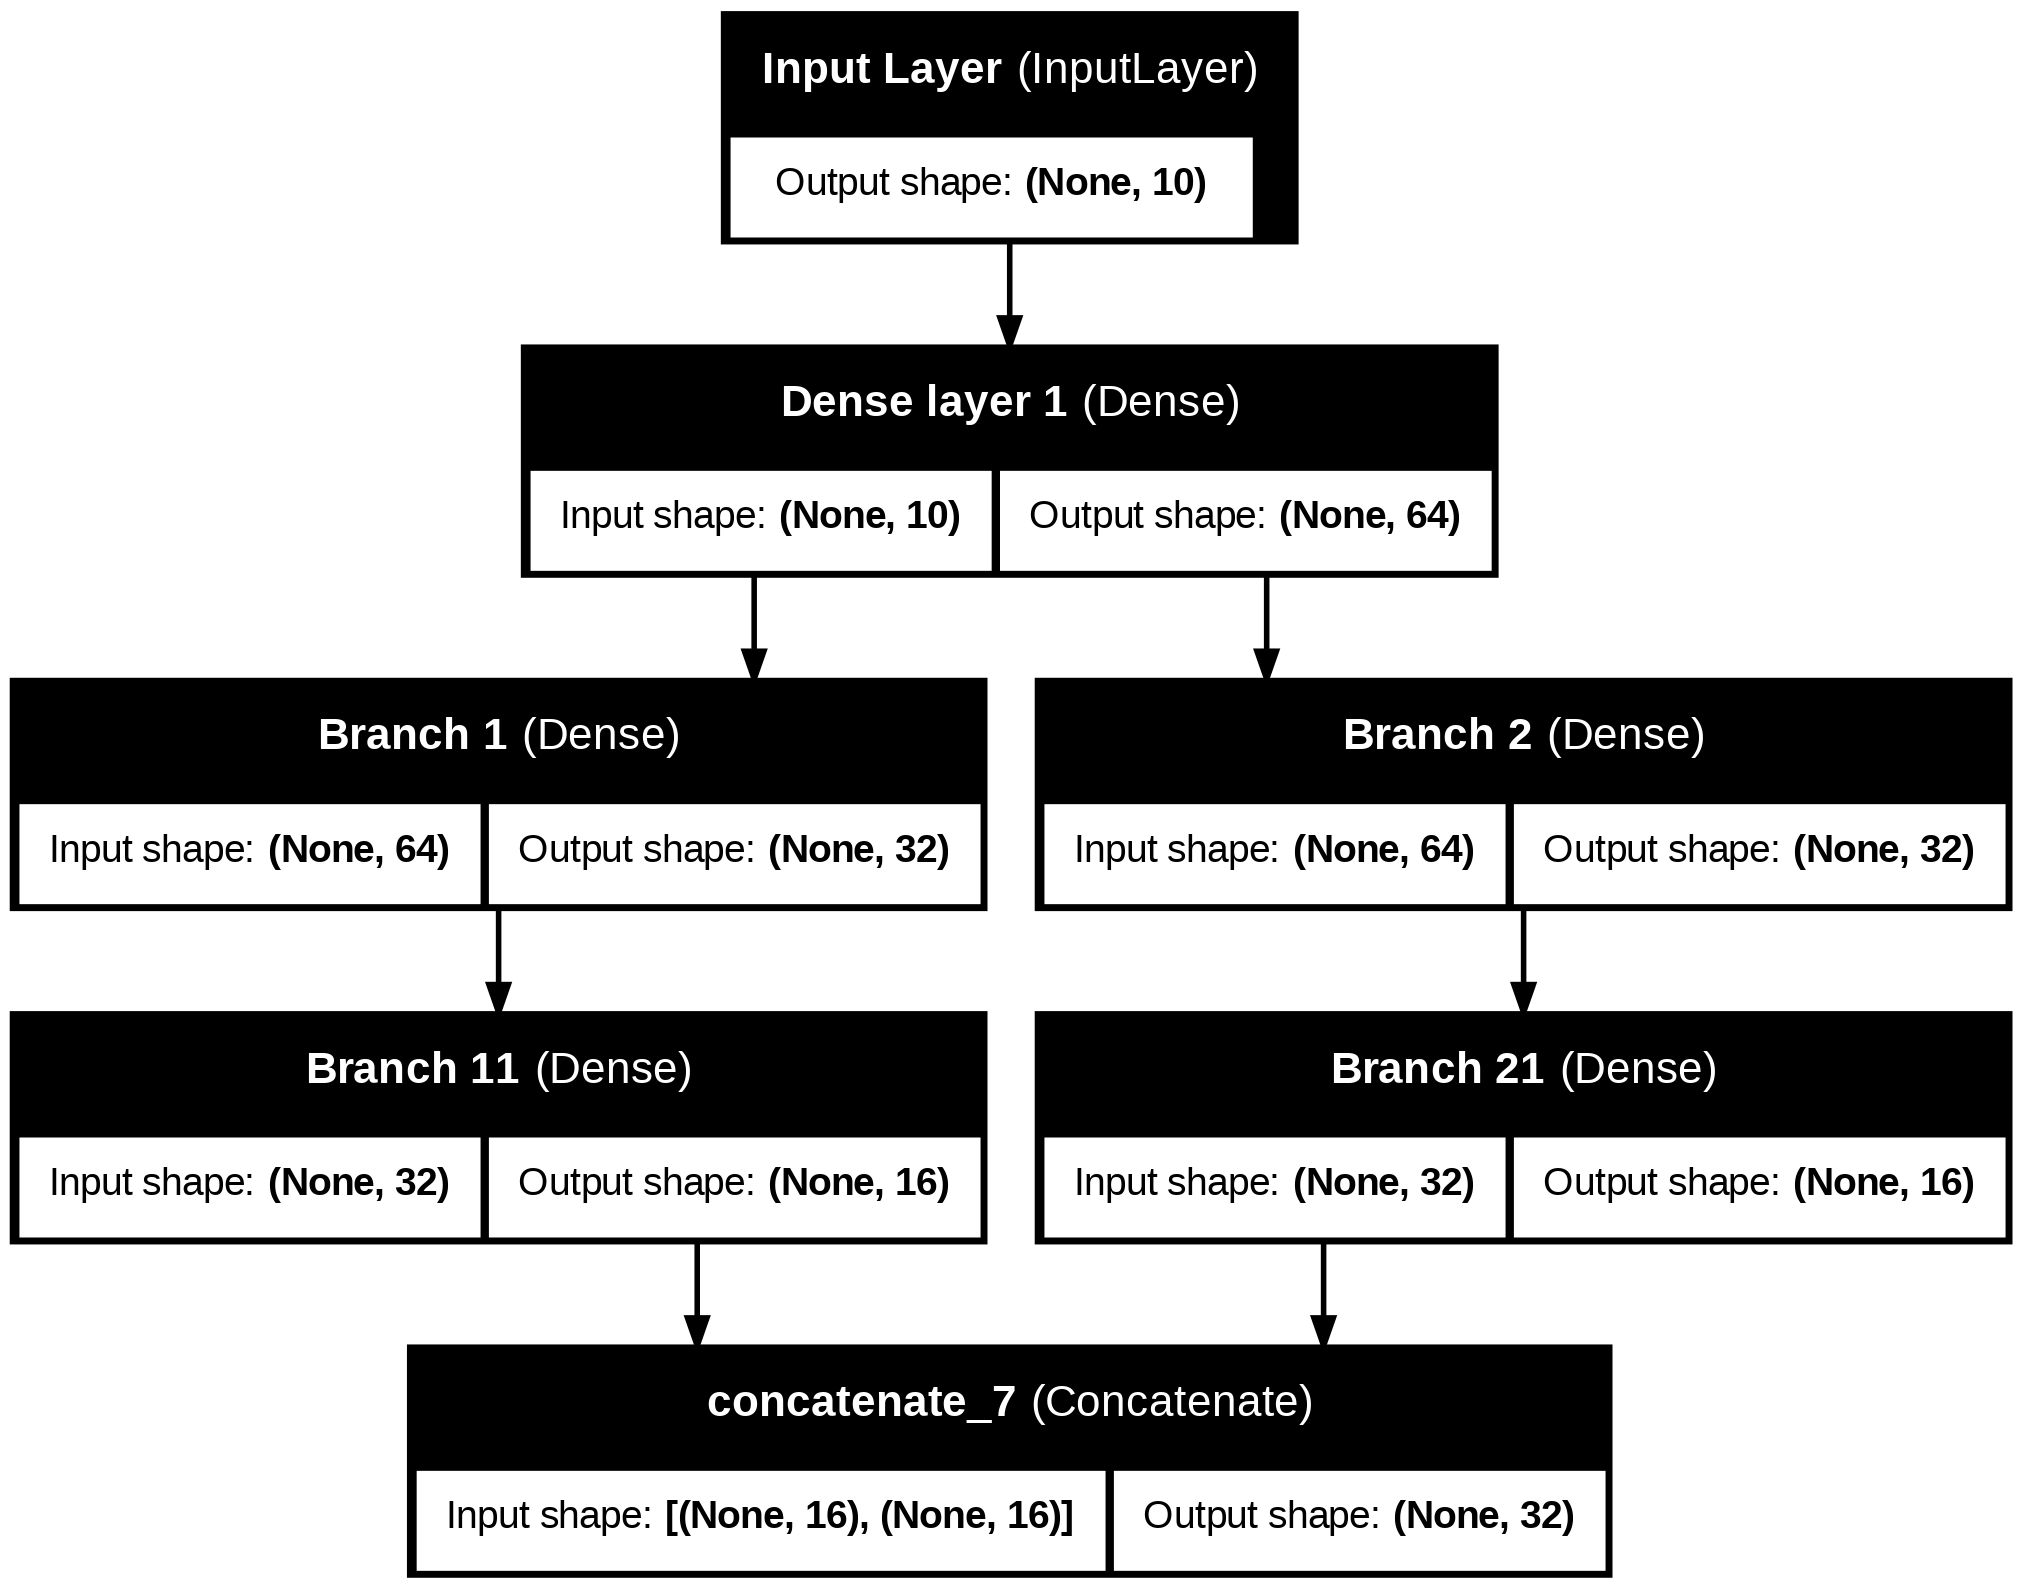

In [58]:
plot_model(model1, show_shapes=True, show_layer_names=True)

### Compiling model

In [60]:
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Another NON linear model

In [77]:
input = Input(shape=(10,),name="Input Layer")
layer1 = Dense(64, activation='relu',name="Dense layer 1")(input)
layer2 = Dense(32, activation='relu',name="Dense layer 2")(layer1)
layer3 = Dense(16, activation='relu',name="Dense layer 3")(layer2)

### Adding a 1st branch

In [78]:
branch1 = Dense(16, activation='relu',name="Branch 1")(layer3)
branch11 = Dense(8, activation='relu',name="Branch 11")(branch1)
branch12 = Dense(1, activation='sigmoid',name="Output Branch 1")(branch11)

### Adding a 2nd branch

In [79]:
branch2 = Dense(16, activation='relu',name="Branch 2")(layer3)
branch21 = Dense(8, activation='relu',name="Branch 21")(branch2)
branch22 = Dense(1, activation='softmax',name="Output Branch 2")(branch21)

### Merging model

In [80]:
model1 = Model(inputs=input, outputs=[branch12, branch22])

### Plotting model

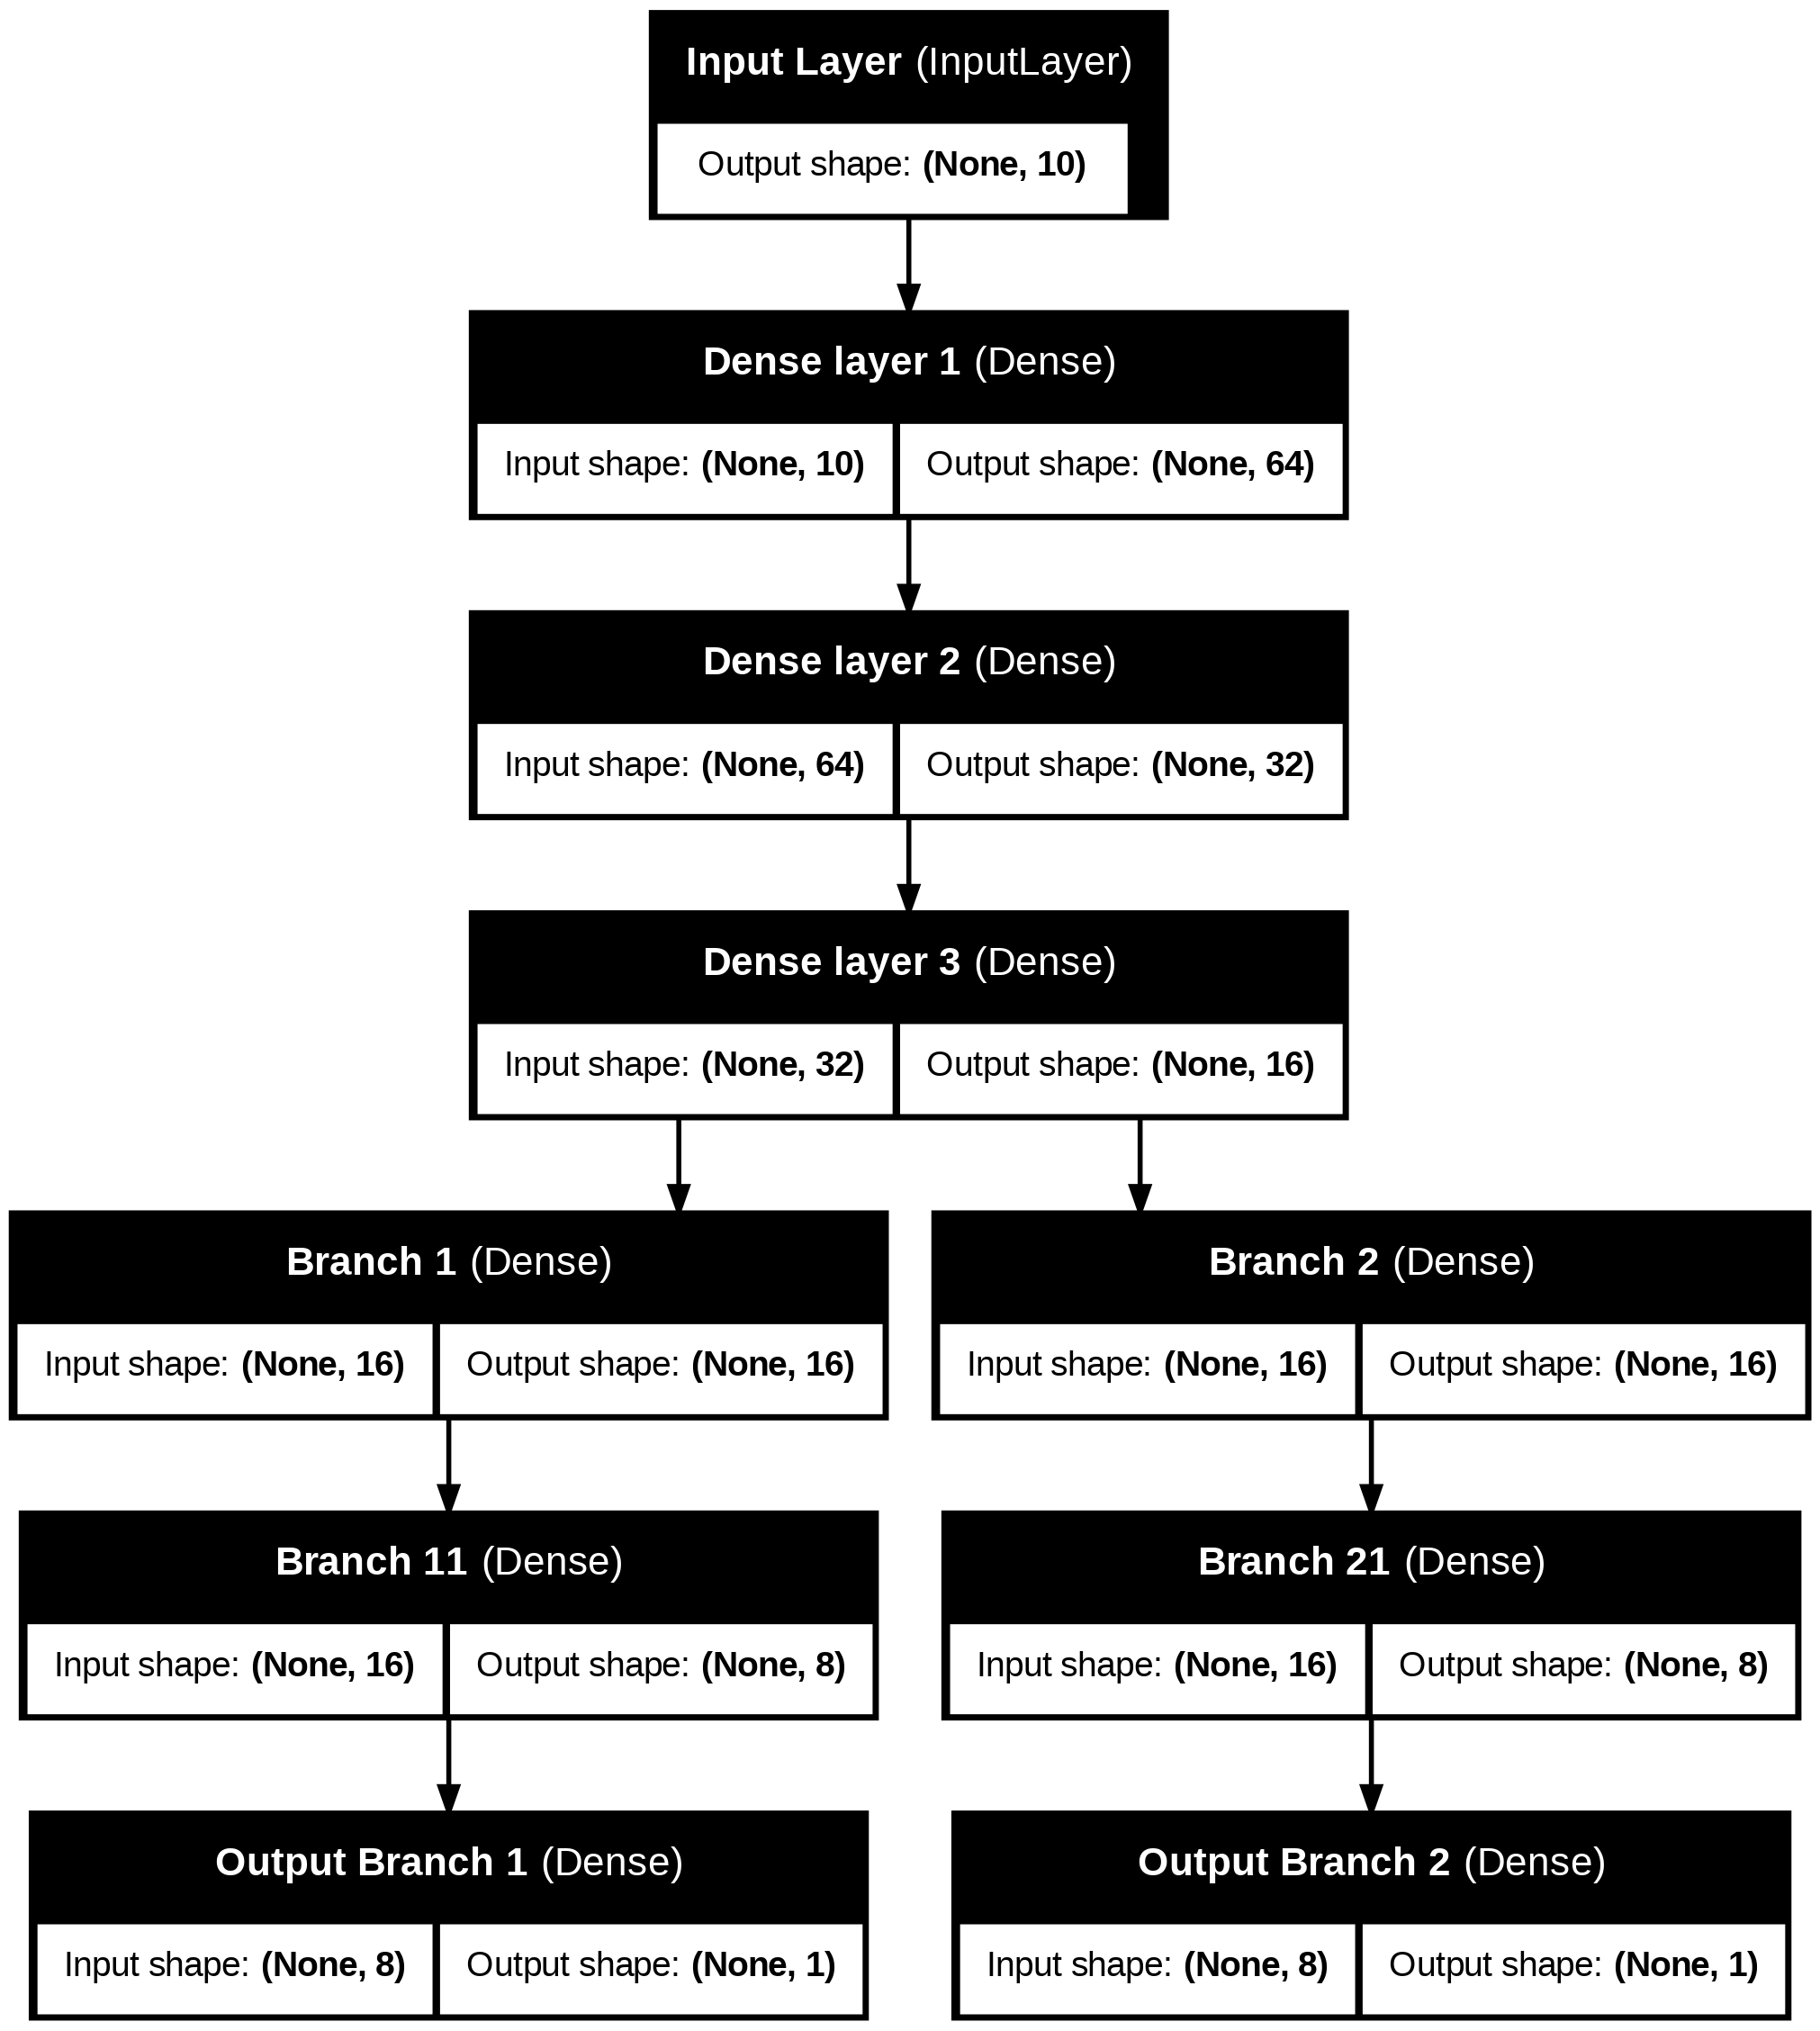

In [81]:
plot_model(model1, show_shapes=True, show_layer_names=True)

### Compiling model

In [82]:
model1.compile(
    optimizer='adam',

    loss={
        'Output Branch 1': 'binary_crossentropy',
        'Output Branch 2': 'mse'
    },

    metrics={
        'Output Branch 1': 'accuracy',
        'Output Branch 2': 'mae'
    }
)

In [83]:
model1.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input Layer         │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense layer 1       │ (None, 64)        │        704 │ Input Layer[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense layer 2       │ (None, 32)        │      2,080 │ Dense layer       │
│ (Dense)             │                   │            │ 1[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense layer 3       │ (None, 16)        │        528 │ Dense layer       │
│ (Dense)             │                   │            │ 2[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Branch 1 (Dense)    │ (None, 16)        │        272 │ Dense layer       │
│                     │                   │            │ 3[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Branch 2 (Dense)    │ (None, 16)        │        272 │ Dense layer       │
│                     │                   │            │ 3[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Branch 11 (Dense)   │ (None, 8)         │        136 │ Branch 1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Branch 21 (Dense)   │ (None, 8)         │        136 │ Branch 2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output Branch 1     │ (None, 1)         │          9 │ Branch 11[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output Branch 2     │ (None, 1)         │          9 │ Branch 21[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,146 (16.20 KB)

 Trainable params: 4,146 (16.20 KB)

 Non-trainable params: 0 (0.00 B)